Imported Need Libraries.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Part A: EDA & Cleaning The Data

In [47]:
# Step--1
# Here now we imported the using seaborn Package.
# In secborn package some Dataset are giving In built DataSets. Now we pick one DataSet.

df_raw = sns.load_dataset('titanic')
print(df_raw.head())
print(' \n**The data extract successfully**\n') 

# Now Imported DataSet Save in offline (.csv file) Format.
df_raw.to_csv("titanic.csv", index=False)
print("Saved row data file to 'titanic.csv'.")

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
 
**The data extract successfully**

Saved row data file to 'titanic.csv'.


In [48]:
# Now we Read back to ensure work from the offline Dataset.
df = pd.read_csv('titanic.csv')
print("\n **Dataset Profile**")
print(f"Shape of DataSet: {df.shape}")
print(f"\n Statistic Summery of Dataset:\n {df.describe()}\n")
print(df.info())
print("\n ----* Missing Values Percentages *----")
missing_per = (df.isna().sum()/ len(df)) *100
print(missing_per[missing_per > 0])
print()


 **Dataset Profile**
Shape of DataSet: (891, 15)

 Statistic Summery of Dataset:
          survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non

In [49]:
# Step---2
# Missing Values Handling.
# if missing values below 5% Drop the Null values.
# if Missing Values Above 5% Impute the values.

# Column [deck] > 77% of values Missing imputation is Unrelible encode 'missing'.
df['deck'] = df['deck'].fillna("missing")

# Column [Age] > 20% of values Missing. Here we Impute with Median (**It take median value of the Age Column**)
df['age'] = df['age'].fillna(df['age'].median())

# Column [embarked]/[embark_town] < 5% of values Missing. So The Data is not Important. we can Drop the Null values.
df = df.dropna(subset=['embarked', 'embark_town'])

print(f"\n Shape after missing values handling: {df.shape}")
df.isna().sum()/len(df)*100


 Shape after missing values handling: (889, 15)


survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
deck           0.0
embark_town    0.0
alive          0.0
alone          0.0
dtype: float64


Report how many outliers each column--->

Outliers in 'AGE' : 65
Outliers in 'fare': 114

Compute mean, median, and mode for fare -->

 Fare - Mean  : 32.10,
 Fare - median: 14.45,
 Fare - Mode  : 8.05


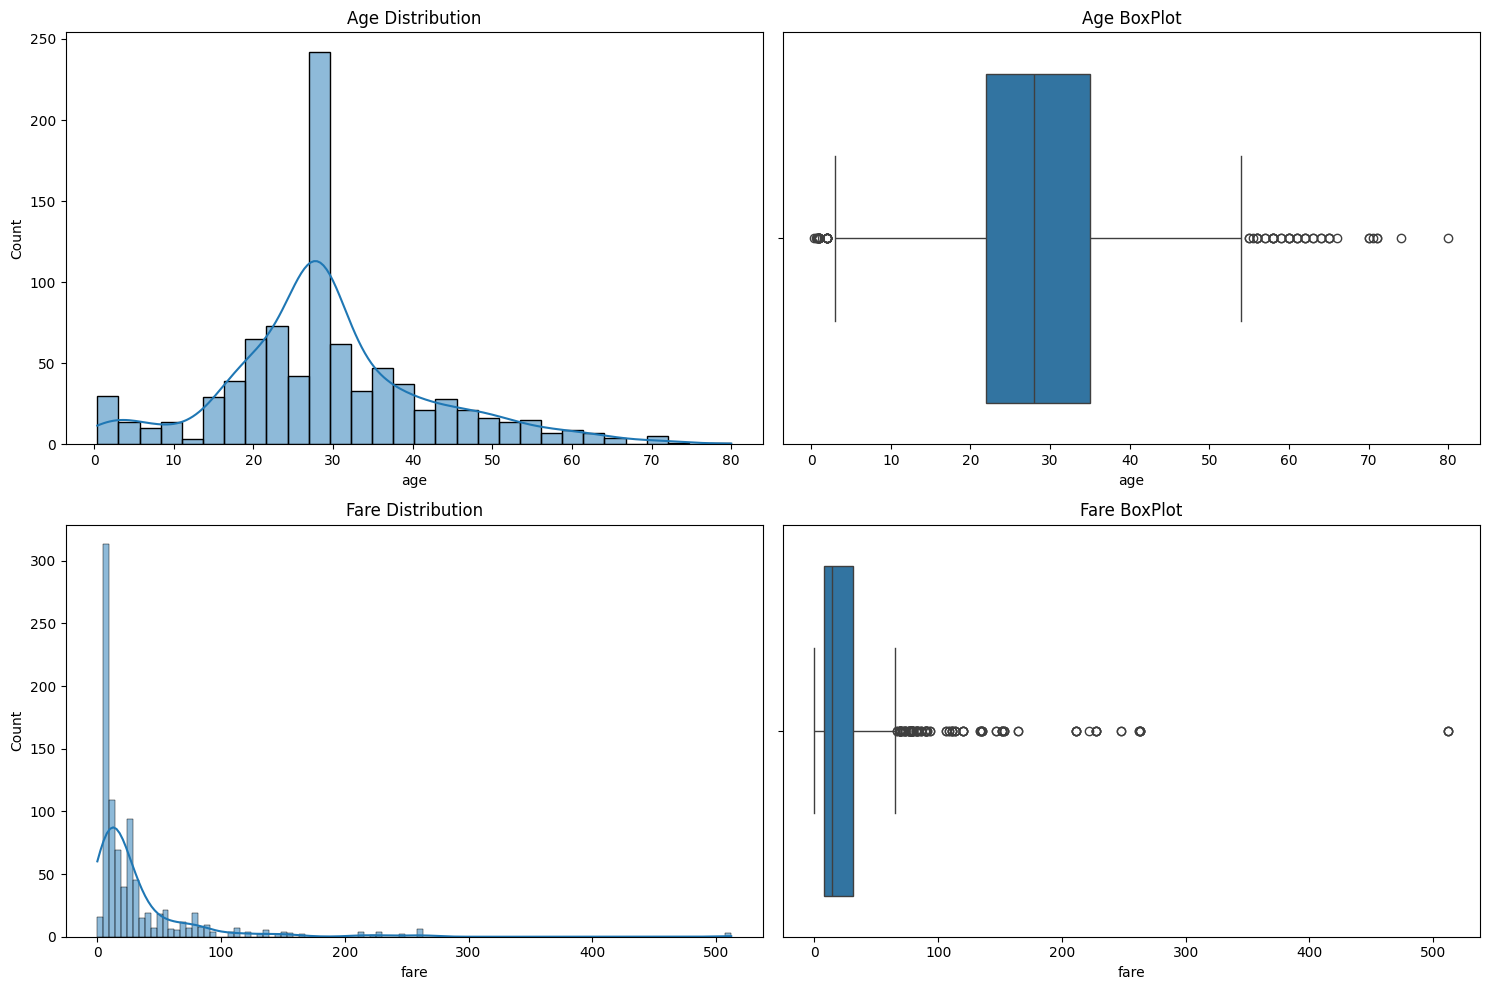


***Plot Image Saved in File suceesfully***


In [50]:
#  Step --3
# Univariate analysis (Outliers using the IQR rules)
# Forumela [Q1 - 1.5xIQR, Q3 + 1.5xIQR]
# report how many outliers each column
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((series < lower_bound) | (series > upper_bound)).sum()
print("\nReport how many outliers each column--->")
print(f"\nOutliers in 'AGE' : {count_outliers(df['age'])}")
print(f"Outliers in 'fare': {count_outliers(df['fare'])}" )

# distribution is right-skewed, left-skewed, or symmetric
# referencing the mean/median/mode ordering.
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]
print("\nCompute mean, median, and mode for fare -->")
print(f"\n Fare - Mean  : {fare_mean:.2f},\n Fare - median: {fare_median:.2f},\n Fare - Mode  : {fare_mode:.2f}")

# Now I'm Ploting a Histogram and Boxplot using [Age, Fare] columns for Univariate analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df['age'], kde=True, ax=axes[0, 0]).set_title("Age Distribution")
sns.boxplot(x=df['age'], ax=axes[0, 1]).set_title("Age BoxPlot")
sns.histplot(df['fare'], kde=True, ax=axes[1, 0]).set_title("Fare Distribution")
sns.boxplot(x=df['fare'],ax=axes[1, 1]).set_title("Fare BoxPlot")
plt.tight_layout()
plt.savefig("Univariate analysis.png")
plt.show()
plt.close()

print("\n***Plot Image Saved in File suceesfully***")

*-*-Survival Rate-*-*
By Sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

By Pclass:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

By Sex And Pclass:
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


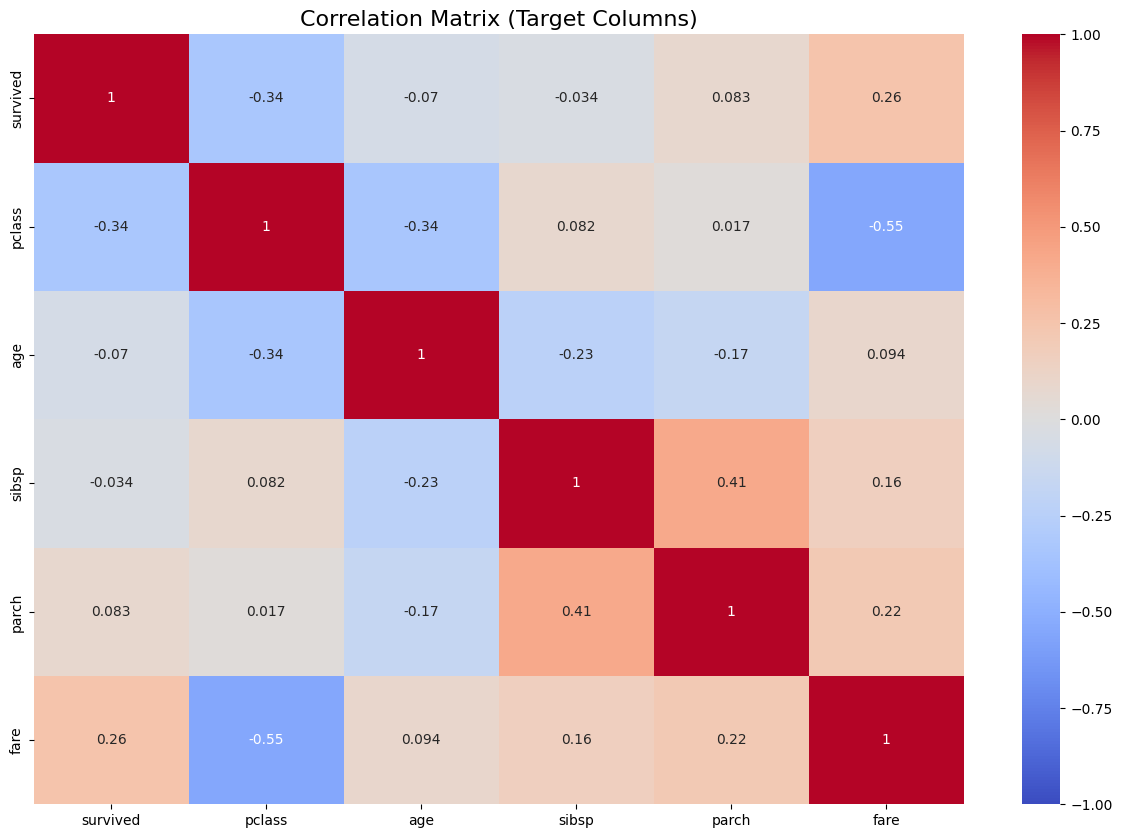

*-*-Bivariate Analysis is Completed-*-*


In [51]:
# Step --4
# Bivariate Analysis
print("*-*-Survival Rate-*-*")
print(f"By Sex:\n{df.groupby('sex')['survived'].mean()}\n")
print(f"By Pclass:\n{df.groupby('pclass')['survived'].mean()}\n")
print(f"By Sex And Pclass:\n{df.groupby(['sex', 'pclass'])['survived'].mean()}")

# correlation matrix restricted
corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmax=1, vmin=-1)
plt.title("Correlation Matrix (Target Columns)", fontsize=16)
plt.savefig("Correlation_heatmap.png")
plt.show()
plt.close()
print("*-*-Bivariate Analysis is Completed-*-*")

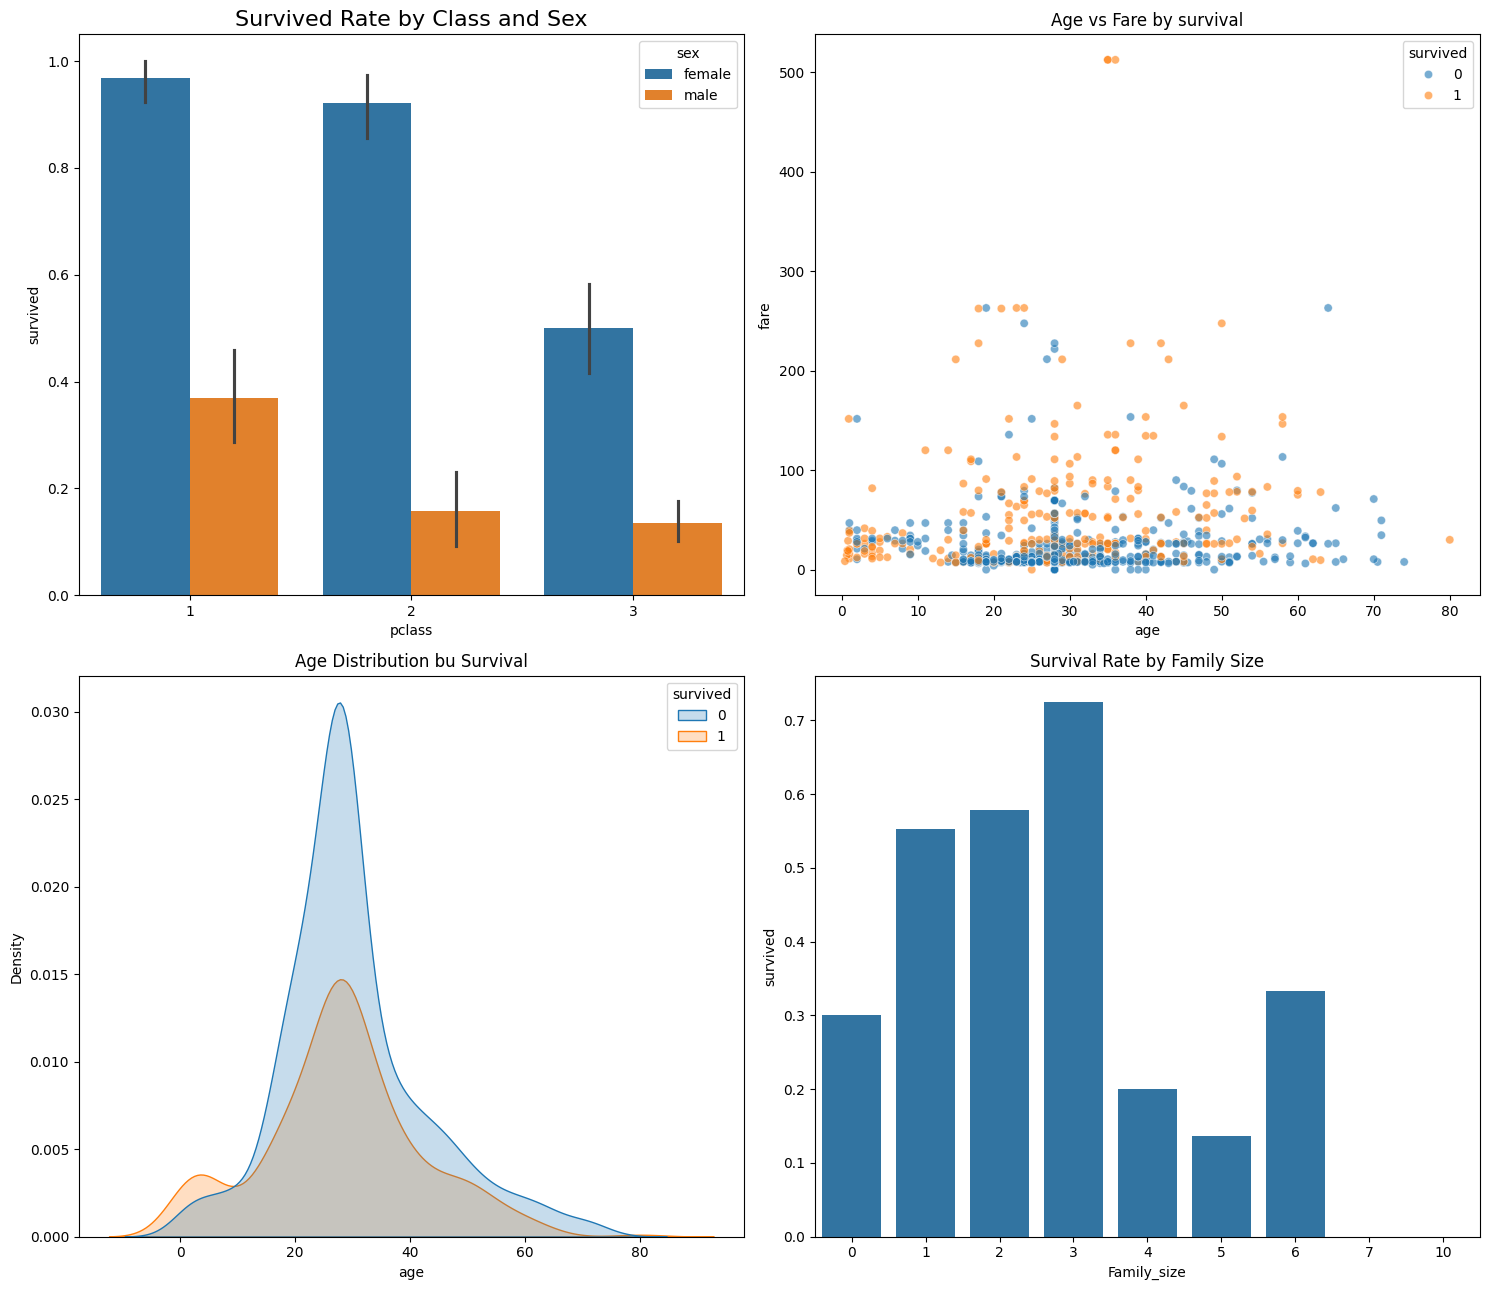

In [52]:
# Step --5
# Multivariate Data Story Charts (combination of bar/box/scatter/heatmap/pair-plot)

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
# Using Barplot chart to find pclass and sex wise survival rate% chart.
sns.barplot(data=df, x='pclass', y='survived', hue='sex', ax=axes[0, 0]).set_title("Survived Rate by Class and Sex", fontsize=16)
# using scatterplot chart to find age and fare wise survival rate.  
sns.scatterplot(data=df, x='age', y='fare', hue='survived', alpha=0.6, ax=axes[0, 1]).set_title("Age vs Fare by survival")
# Using kdeplot chart  age distribution by survival rate.
sns.kdeplot(data=df, x='age', hue='survived', fill=True, ax=axes[1, 0]).set_title("Age Distribution bu Survival")
# Using barplot chart family size wise survival rate
df['Family_size'] = df['sibsp'] + df['parch']
sns.barplot(data=df, x='Family_size', y='survived', ax=axes[1,1], errorbar=None).set_title("Survival Rate by Family Size")
plt.tight_layout()
plt.savefig("multivariate_story.png")
plt.show()
plt.close()

In [53]:
from scipy import stats

# Stap --6
# Exploratory Sanity check (standardscaler)
print("*-*-Now we do Exploratory Standardization Sanity check-*-* ")
print("\nBefore Standardization The Age and Fare:")
print(df[['age', 'fare']].agg(['mean', 'std']))

# standardize age and fare using the z-score formula z = (x − mean) / std on the full cleaned DataFrame 
df_standardized = df.copy()
df_standardized['age_z'] = stats.zscore(df_standardized['age'])
df_standardized['fare_z'] = stats.zscore(df_standardized['fare'])

print("\nAfter Standardization (using Z-score formula):")
print(df_standardized[['age_z', 'fare_z']].agg(['mean', 'std']).round(4))
print("\n EDA part Completed.")

*-*-Now we do Exploratory Standardization Sanity check-*-* 

Before Standardization The Age and Fare:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Standardization (using Z-score formula):
       age_z  fare_z
mean  0.0000  0.0000
std   1.0006  1.0006

 EDA part Completed.


In [56]:
df.to_csv("Eda_Titanic.csv", index=False)
print("EDA Claned Dataset Ready for Training The Model")

EDA Claned Dataset Ready for Training The Model
